In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')
sns.set_context('notebook')

df_default = pd.read_csv('../data/hotel_bookings.csv')
display(df_default.shape)
df_default.describe(include='all')

(119390, 32)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [2]:
df_default.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [3]:
#printing share of null values per column
share_nulls = {}
n_rows = len(df_default)
for colname in df_default.columns:
    nulls_pcntg = df_default[colname].isnull().sum() / n_rows * 100
    if nulls_pcntg>0:
        share_nulls[colname] = nulls_pcntg

for colname,share_of_nulls in share_nulls.items():
     print(f'Column {colname} has null share of {share_nulls[colname]:.2f}%')

Column children has null share of 0.00%
Column country has null share of 0.41%
Column agent has null share of 13.69%
Column company has null share of 94.31%


In [4]:
df_default.children = df_default.children.fillna(0) #we assume na children = no children

df_default.country = df_default.country.fillna('Unknown') #swapping na country to "Unknown"

df_default.company = df_default.company.fillna('Unknown') #swapping na company to "Unknown"

df_default["arrival_date"] = pd.to_datetime(
    df_default["arrival_date_year"].astype(str) + " " +
    df_default["arrival_date_month"] + " " +
    df_default["arrival_date_day_of_month"].astype(str)) #constructing arrival date variable in YYYY-MM-DD format

df_default["arrival_date_year"] = df_default["arrival_date_year"].astype(int)

import calendar
month_order = list(calendar.month_name)[1:]
df_default['arrival_date_month'] = pd.Categorical(df_default['arrival_date_month'], categories=month_order, ordered=True)
df_default.sort_values('arrival_date', inplace=True)

df_default.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
75559,City Hotel,0,257,2015,July,27,1,0,2,1,...,6.0,Unknown,0,Transient,80.0,0,0,Check-Out,2015-07-03,2015-07-01
75560,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75561,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75562,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01


In [5]:
#reformatting column names for ease of use
for column in df_default.columns:
    df_default.rename(columns={column: column.replace('_', ' ').title().replace(' ', '')}, inplace=True)

df_default.rename(columns={'Adr': 'DailyRate'}, inplace=True)

In [6]:
df_default.columns

Index(['Hotel', 'IsCanceled', 'LeadTime', 'ArrivalDateYear',
       'ArrivalDateMonth', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth',
       'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children',
       'Babies', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel',
       'IsRepeatedGuest', 'PreviousCancellations',
       'PreviousBookingsNotCanceled', 'ReservedRoomType', 'AssignedRoomType',
       'BookingChanges', 'DepositType', 'Agent', 'Company',
       'DaysInWaitingList', 'CustomerType', 'DailyRate',
       'RequiredCarParkingSpaces', 'TotalOfSpecialRequests',
       'ReservationStatus', 'ReservationStatusDate', 'ArrivalDate'],
      dtype='str')

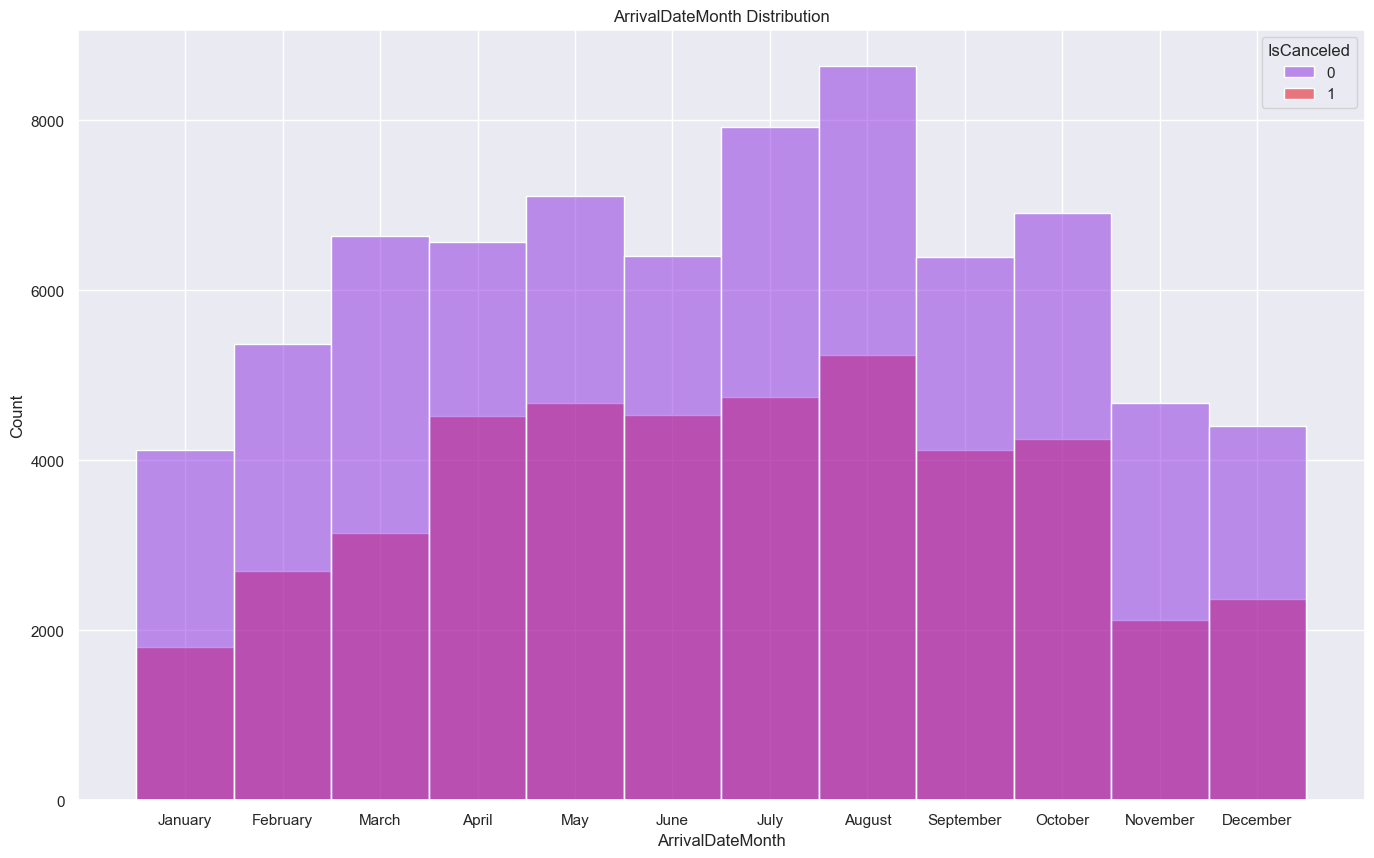

In [7]:
from plotter_module import MultiPlotter9000
plotter = MultiPlotter9000()
plotter.multiplot_histogram(data=df_default[['ArrivalDateMonth','IsCanceled']], columns=['ArrivalDateMonth'], hue_val='IsCanceled')

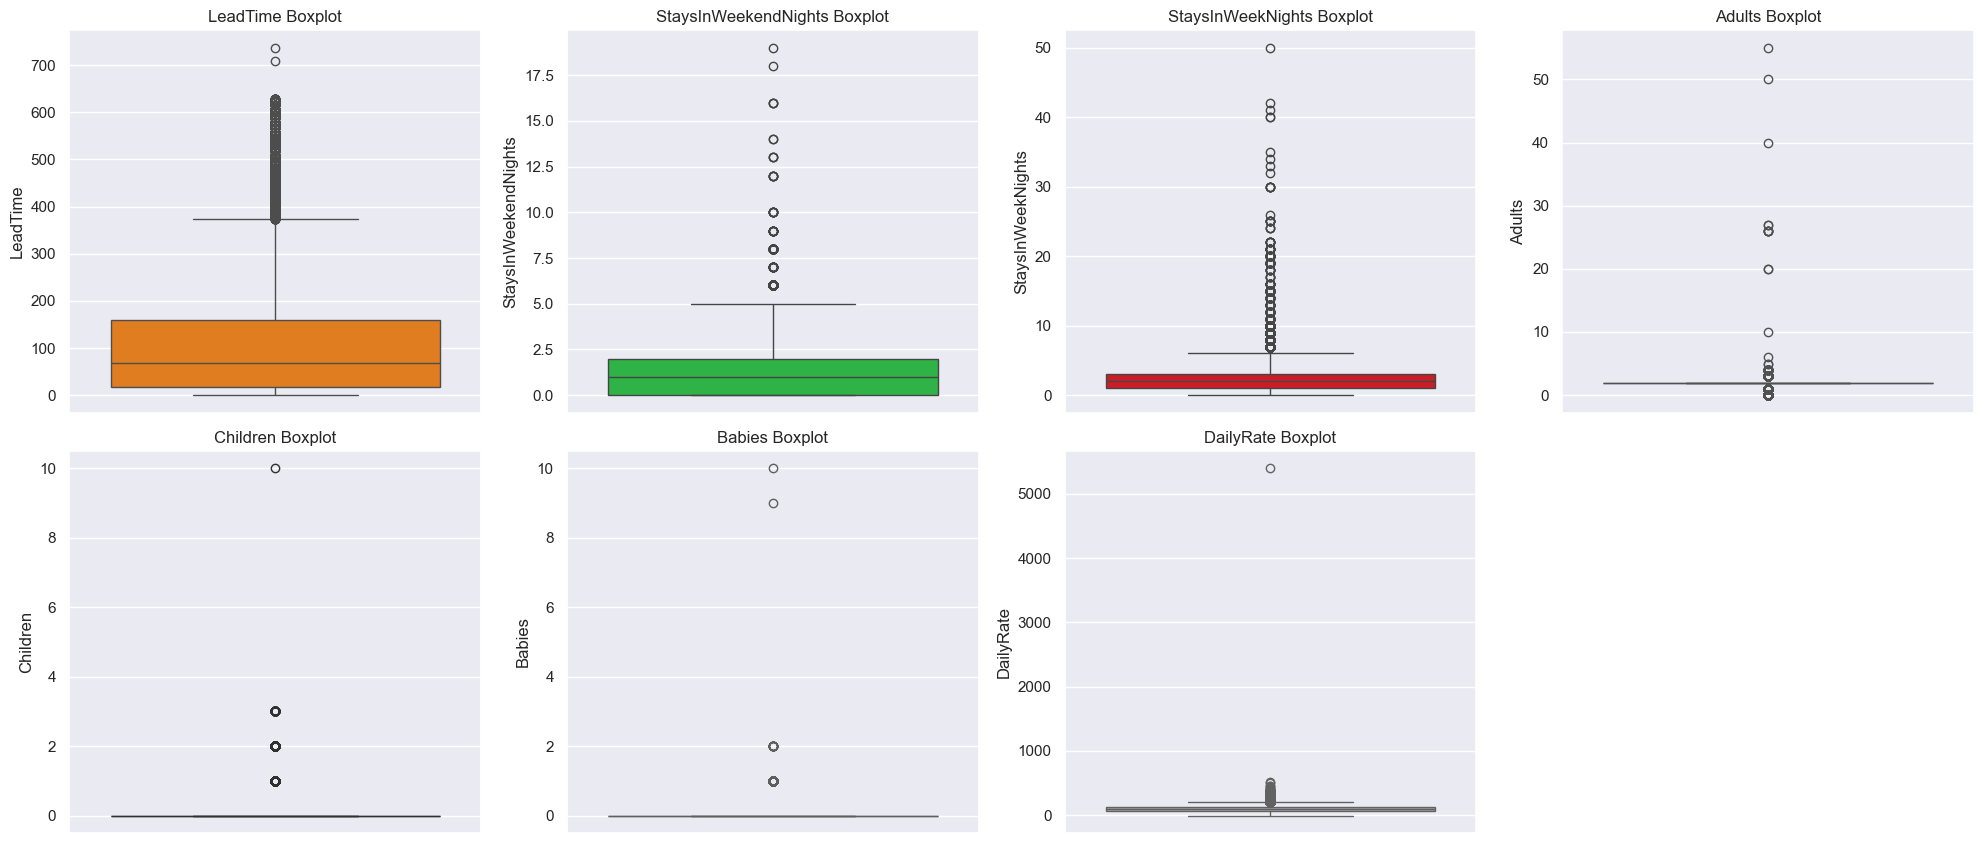

In [8]:
plotter.multiplot_boxplot(data=df_default, columns=["LeadTime",
    "StaysInWeekendNights",
    "StaysInWeekNights",
    "Adults",
    "Children", "Babies", 'DailyRate'
    ])

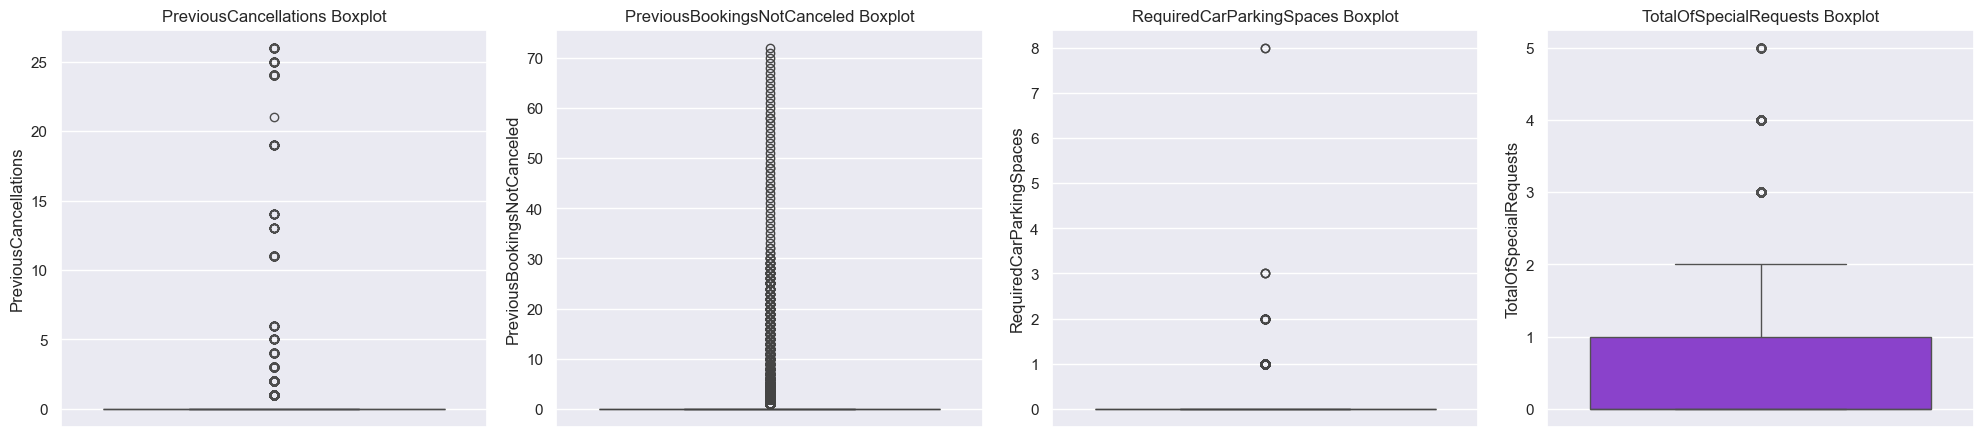

In [9]:
plotter.multiplot_boxplot(data=df_default, columns=[
    "PreviousCancellations",
    "PreviousBookingsNotCanceled",
    "RequiredCarParkingSpaces",
    "TotalOfSpecialRequests"])

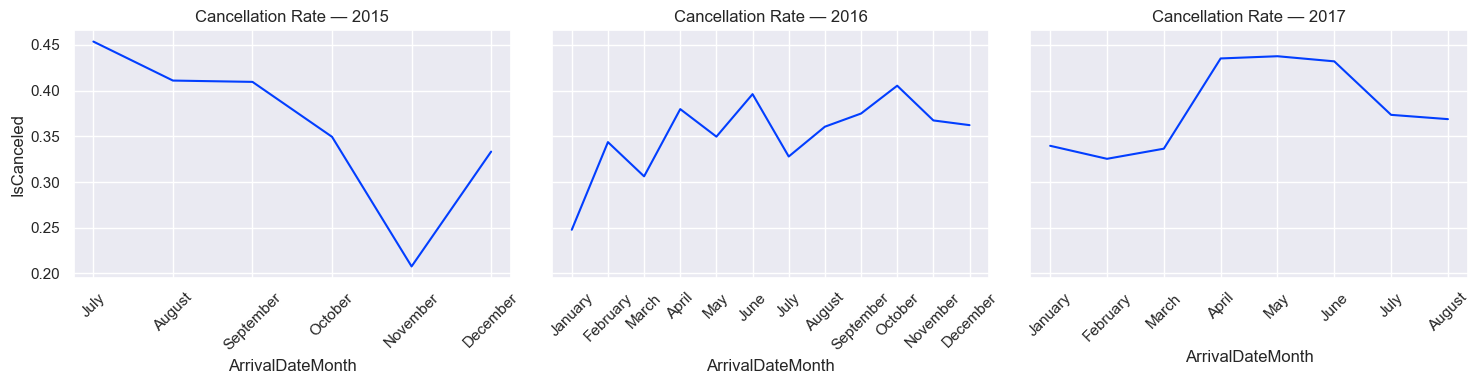

In [10]:
years = sorted(df_default.ArrivalDateYear.unique())

fig, axes = plt.subplots(1, len(years), figsize=(5 * len(years), 4), sharey=True)
for ax, year in zip(axes, years):
    by_month = (
        df_default[df_default.ArrivalDateYear == year]
        .groupby('ArrivalDateMonth')['IsCanceled']
        .mean()
        .reset_index()
    )

    sns.lineplot(data=by_month, x='ArrivalDateMonth', y='IsCanceled', ax=ax)
    ax.set_title(f'Cancellation Rate — {year}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

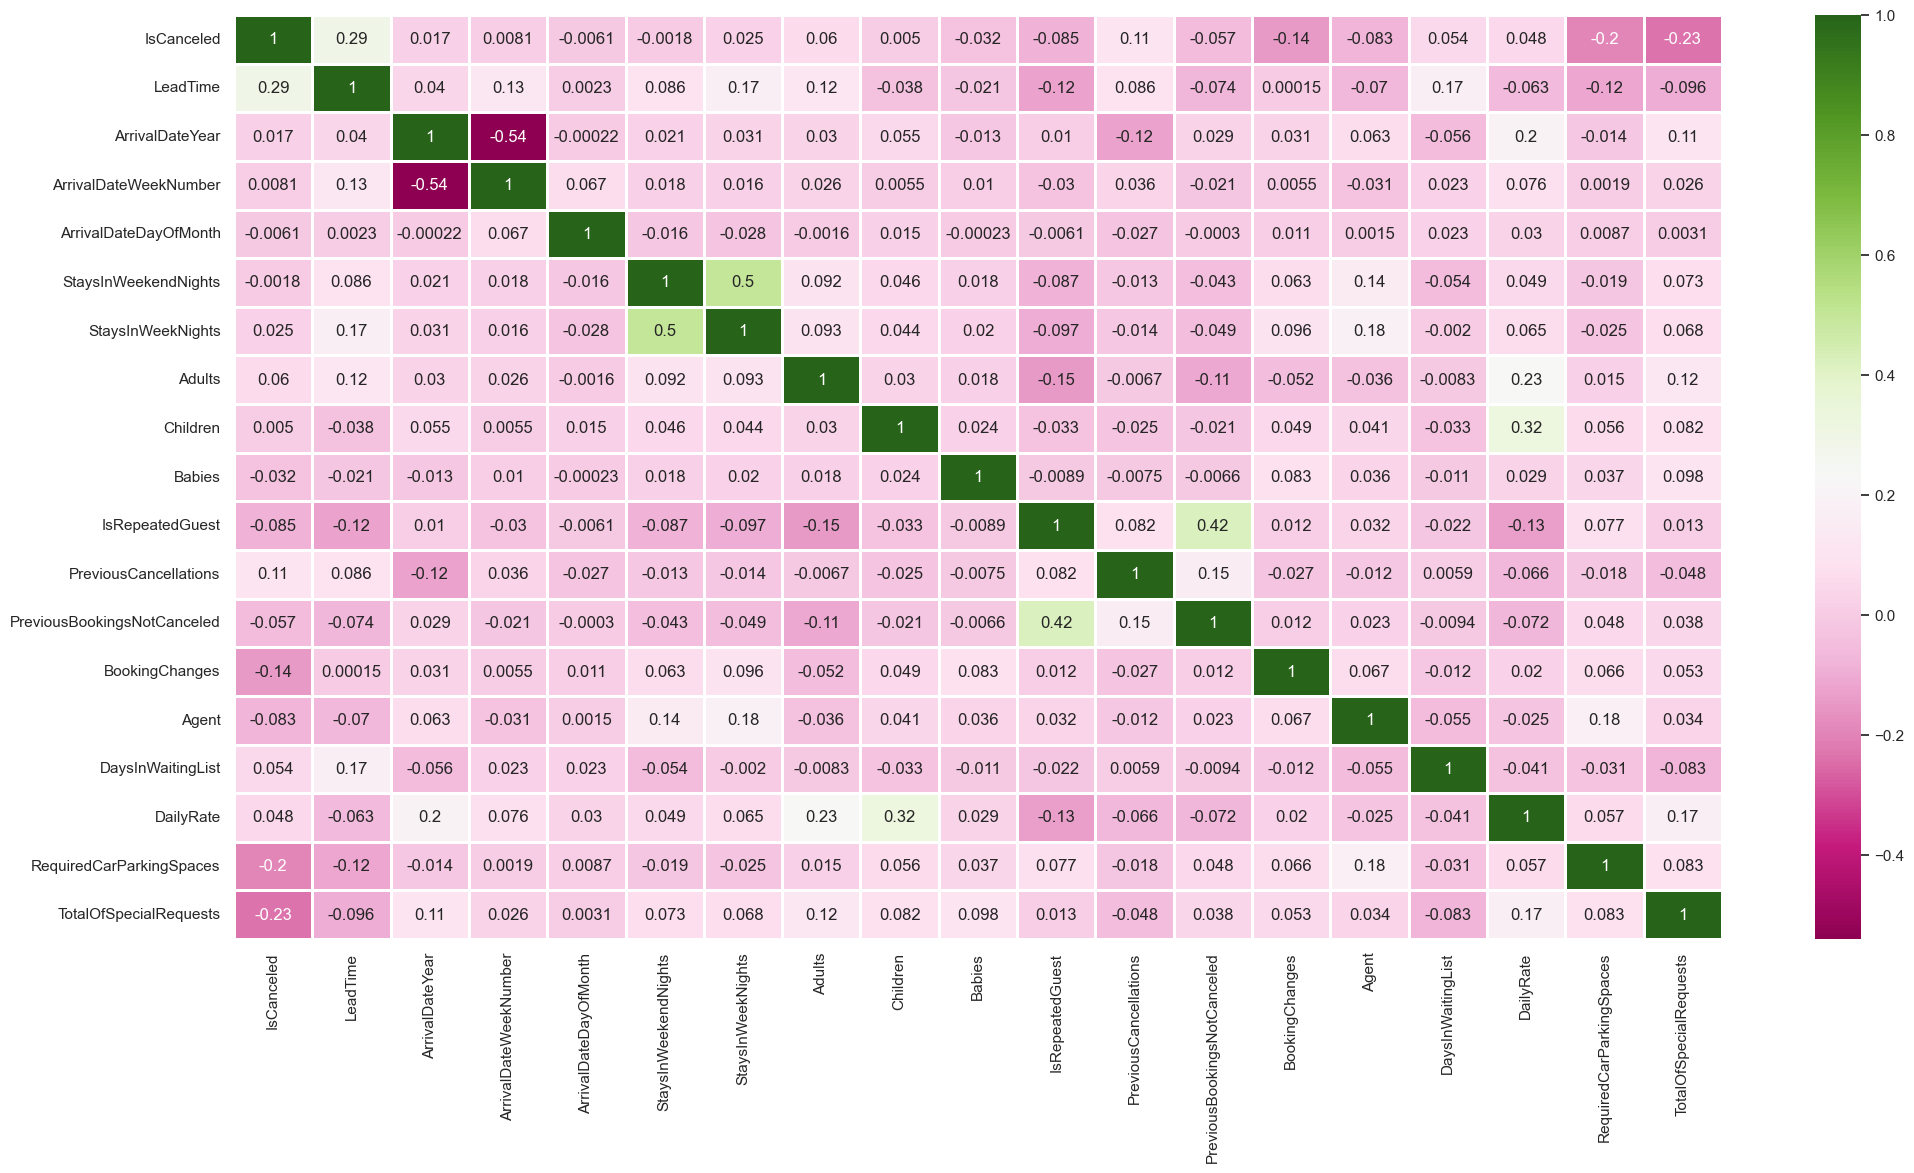

In [11]:
plt.figure(figsize = (24, 12))

corr = df_default.select_dtypes(include='number').corr()
sns.heatmap(corr, annot = True, linewidths = 1, cmap='PiYG')
plt.show()

In [12]:
#start feature engineering
MODEL_DATA_PARENT = df_default.copy()
num_features = [
    "LeadTime",
    "StaysInWeekendNights",
    "StaysInWeekNights",
    "Adults",
    "Children",
    "Babies",
    "IsRepeatedGuest",
    "PreviousCancellations",
    "PreviousBookingsNotCanceled",
    "RequiredCarParkingSpaces",
    "TotalOfSpecialRequests",
    "DailyRate"]

cat_features = [
    "Hotel",
    "ArrivalDateMonth",
    "Meal",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "DepositType",
    "CustomerType"]

df_num = MODEL_DATA_PARENT[num_features]
df_cat = MODEL_DATA_PARENT[cat_features]
target = MODEL_DATA_PARENT['IsCanceled']

In [13]:
df_num.head()

,LeadTime,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,RequiredCarParkingSpaces,TotalOfSpecialRequests,DailyRate
0,342,0,0,2,0.0,0,0,0,0,0,0,0.0
75559,257,0,2,1,0.0,0,0,0,0,0,0,80.0
75560,257,0,2,2,0.0,0,0,0,0,0,0,101.5
75561,257,0,2,2,0.0,0,0,0,0,0,0,101.5
75562,257,0,2,2,0.0,0,0,0,0,0,0,101.5


In [14]:
df_cat.head()

,Hotel,ArrivalDateMonth,Meal,MarketSegment,DistributionChannel,ReservedRoomType,DepositType,CustomerType
0,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient
75559,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75560,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75561,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75562,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient


In [15]:
print('Unique Values per categorical feature:\n')
for feature in df_cat.columns:
    print(f'{'-'*170}\nColumn {feature}\'s unique values: {' | '.join(list(df_cat[feature].astype(str).unique()))}')
print('-'*170)

Unique Values per categorical feature:

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Hotel's unique values: Resort Hotel | City Hotel
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column ArrivalDateMonth's unique values: July | August | September | October | November | December | January | February | March | April | May | June
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Meal's unique values: BB | HB | FB | SC | Undefined
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Marke

In [16]:
model_data = pd.concat([df_num, df_cat], axis=1)

X_train,  X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(model_data, target, test_size=0.2, random_state=42)

In [17]:
#building pipelines

#categorical pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

#numeric pipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#column transformer
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

#full pipeline
model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

#model fit with pipeline
model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [18]:
from sklearn.metrics import roc_auc_score, recall_score

y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1 (canceled)
roc_auc = roc_auc_score(Y_test, y_pred_proba)

y_pred_class = model.predict(X_test)
recall = recall_score(Y_test, y_pred_class)        # recall of the positive class

In [19]:
roc_auc,recall

(0.8510136481415903, 0.5954389965792475)